# OncoResolve: Temporal & Clinical Longitudinal Survival Analysis Pipeline

**Version**: 3.5.0  
**Discovery Cohort**: TCGA-BRCA ($N=784$ Discovery, $N=197$ Holdout)  
**Validation Cohorts**: METABRIC ($N=1,756$), SCAN-B ($N=340$), SMC ($N=168$)  

### Pipeline Overview
1. Multi-Endpoint Time-to-Event Survival Analysis (Overall Survival OS, Relapse-Free Survival RFS).
2. Horizon-Specific Binary ROC & AUC Performance Dynamics.
3. Landmark Survival & Conditional Mortality Risk Trajectories.
4. Overall Survival (OS) Mortality Hazard Trajectories.


## Section 1: Setup & Data Integration & Longitudinal Follow-up Harmonization

We first import the required analytical libraries, configure plotting aesthetics, load the main transcriptomics dataset (`breast_cancer.parquet`), and merge it with patient-level clinical records (`Breast_TCGA_BRCA_clinical.csv`).

In [1]:
from oncoresolve.imputation import NIPALS_PCA_Imputer, EM_PCA_Imputer, compute_imputation_metrics
from lifelines import NelsonAalenFitter
from sklearn.metrics import roc_curve, auc

import seaborn as sns
SUBTYPE_COLORS = {
    'LumA': '#3498db', 'LumB': '#2ecc71', 'Basal': '#e74c3c', 'Her2': '#9b59b6', 'Normal': '#95a5a6',
    'luminal_A': '#3498db', 'luminal_B': '#2ecc71', 'basal': '#e74c3c', 'her2': '#9b59b6', 'normal': '#95a5a6'
}


from scipy.stats import f_oneway, kruskal, spearmanr, pearsonr
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import matplotlib.pyplot as plt

# Standardized Reproducibility & Path Architecture (Absolute Path Resolution & Headless Resilience)
import os, sys, warnings
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.pyplot as _plt
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = (cwd.parent if cwd.name == "notebooks" else cwd).resolve()
DATA_DIR = (PROJECT_ROOT / "data").resolve()
RAW_DATA_DIR = (DATA_DIR / "raw").resolve()
PROCESSED_DATA_DIR = (DATA_DIR / "processed").resolve()
ARTIFACT_DIR = (DATA_DIR / "artifacts").resolve()
RESULTS_DIR = (PROJECT_ROOT / "results").resolve()
NB_DIR = (PROJECT_ROOT / "notebooks").resolve()

# Aliases for cross-notebook compatibility
PROCESSED_DIR = PROCESSED_DATA_DIR
RAW_DIR = RAW_DATA_DIR
EXT_DIR = (DATA_DIR / "external_cohort").resolve()
ARTIFACTS_DIR = ARTIFACT_DIR
data_dir = str(DATA_DIR)
raw_dir = str(RAW_DATA_DIR)
processed_dir = str(PROCESSED_DATA_DIR)
art_dir = str(ARTIFACT_DIR)
results_dir = str(RESULTS_DIR)

for d in [DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, ARTIFACT_DIR, RESULTS_DIR, EXT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not getattr(_plt, '_is_safe_patched', False):
    _orig_savefig = _plt.savefig
    def _safe_savefig(fname, *args, **kwargs):
        try:
            return _orig_savefig(fname, *args, **kwargs)
        except Exception as _e:
            print(f"[WARNING] Figure save to {fname} skipped: {_e}")
    _plt.savefig = _safe_savefig
    _plt._is_safe_patched = True

def safe_joblib_dump(value, filename, **kwargs):
    p = Path(filename).resolve()
    p.parent.mkdir(parents=True, exist_ok=True)
    if p.exists():
        try:
            p.unlink()
        except Exception:
            pass
    return joblib.dump(value, str(p), **kwargs)

def safe_to_parquet(df, filename, **kwargs):
    p = Path(filename).resolve()
    p.parent.mkdir(parents=True, exist_ok=True)
    if p.exists():
        try:
            p.unlink()
        except Exception:
            pass
    return df.to_parquet(str(p), **kwargs)

def safe_to_csv(df, filename, **kwargs):
    p = Path(filename).resolve()
    p.parent.mkdir(parents=True, exist_ok=True)
    if p.exists():
        try:
            p.unlink()
        except Exception:
            pass
    return df.to_csv(str(p), **kwargs)


In [2]:
# 1. Load Main Expression & Clinical Data
expr_df = pd.read_parquet(PROCESSED_DIR / 'breast_cancer.parquet')
clin_df = pd.read_csv(RAW_DIR / 'Breast_TCGA_BRCA_clinical.csv')

# Extract TCGA Patient Barcode (first 12 characters: TCGA-XX-XXXX)
sample_pids = expr_df.index.to_series().str.rsplit('-', n=1).str[0]

# Index clinical data by patient_id
clin_df_indexed = clin_df.drop_duplicates(subset=['patient_id']).set_index('patient_id')

# Merge clinical metadata matching the 981 expression samples
merged_meta = clin_df_indexed.reindex(sample_pids)
merged_meta.index = expr_df.index  # restore sample barcodes

# Harmonize Subtype Column (clean prefix)
merged_meta['Subtype_Clean'] = merged_meta['SUBTYPE'].str.replace('BRCA_', '', regex=False)

# Convert Temporal Clinical Endpoints to Numeric
endpoints = ['OS', 'DFS', 'PFS', 'DSS']
for ep in endpoints:
    mo_col = f'{ep}_MONTHS'
    st_col = f'{ep}_STATUS'
    if mo_col in merged_meta.columns:
        merged_meta[mo_col] = pd.to_numeric(merged_meta[mo_col], errors='coerce')
    if st_col in merged_meta.columns:
        # Extract binary status code (1: event occurred, 0: censored)
        merged_meta[f'{ep}_EVENT'] = merged_meta[st_col].astype(str).str.extract(r'(\d+)')[0].astype(float)

# Print Summary Table
summary_list = []
for ep in endpoints:
    mo_col = f'{ep}_MONTHS'
    ev_col = f'{ep}_EVENT'
    valid = merged_meta.dropna(subset=[mo_col, ev_col])
    n_total = len(valid)
    n_events = int(valid[ev_col].sum())
    median_fu = valid[mo_col].median()
    iqr_25 = valid[mo_col].quantile(0.25)
    iqr_75 = valid[mo_col].quantile(0.75)
    summary_list.append({
        'Endpoint': ep,
        'Full Name': {'OS': 'Overall Survival', 'DFS': 'Disease-Free Survival', 'PFS': 'Progression-Free Survival', 'DSS': 'Disease-Specific Survival'}[ep],
        'Valid Samples': n_total,
        'Events Count': n_events,
        'Censored Count': n_total - n_events,
        'Event Rate (%)': f'{n_events/n_total*100:.1f}%',
        'Median Follow-up (Mo)': f'{median_fu:.1f} ({iqr_25:.1f} - {iqr_75:.1f})'
    })

summary_df = pd.DataFrame(summary_list)
print("=== TCGA-BRCA Longitudinal Follow-up Summary ===")
display(summary_df)

=== TCGA-BRCA Longitudinal Follow-up Summary ===


,Endpoint,Full Name,Valid Samples,Events Count,Censored Count,Event Rate (%),Median Follow-up (Mo)
0,OS,Overall Survival,981,132,849,13.5%,27.0 (14.7 - 55.7)
1,DFS,Disease-Free Survival,852,74,778,8.7%,25.0 (14.2 - 52.9)
2,PFS,Progression-Free Survival,980,128,852,13.1%,25.2 (14.0 - 52.9)
3,DSS,Disease-Specific Survival,962,69,893,7.2%,26.2 (14.5 - 55.4)


## Section 2: Multi-Endpoint Time-to-Event Survival Analysis

In this section, we analyze survival probabilities across all four longitudinal endpoints (**Overall Survival**, **Disease-Free Survival**, **Progression-Free Survival**, and **Disease-Specific Survival**) stratified by PAM50 molecular subtypes.

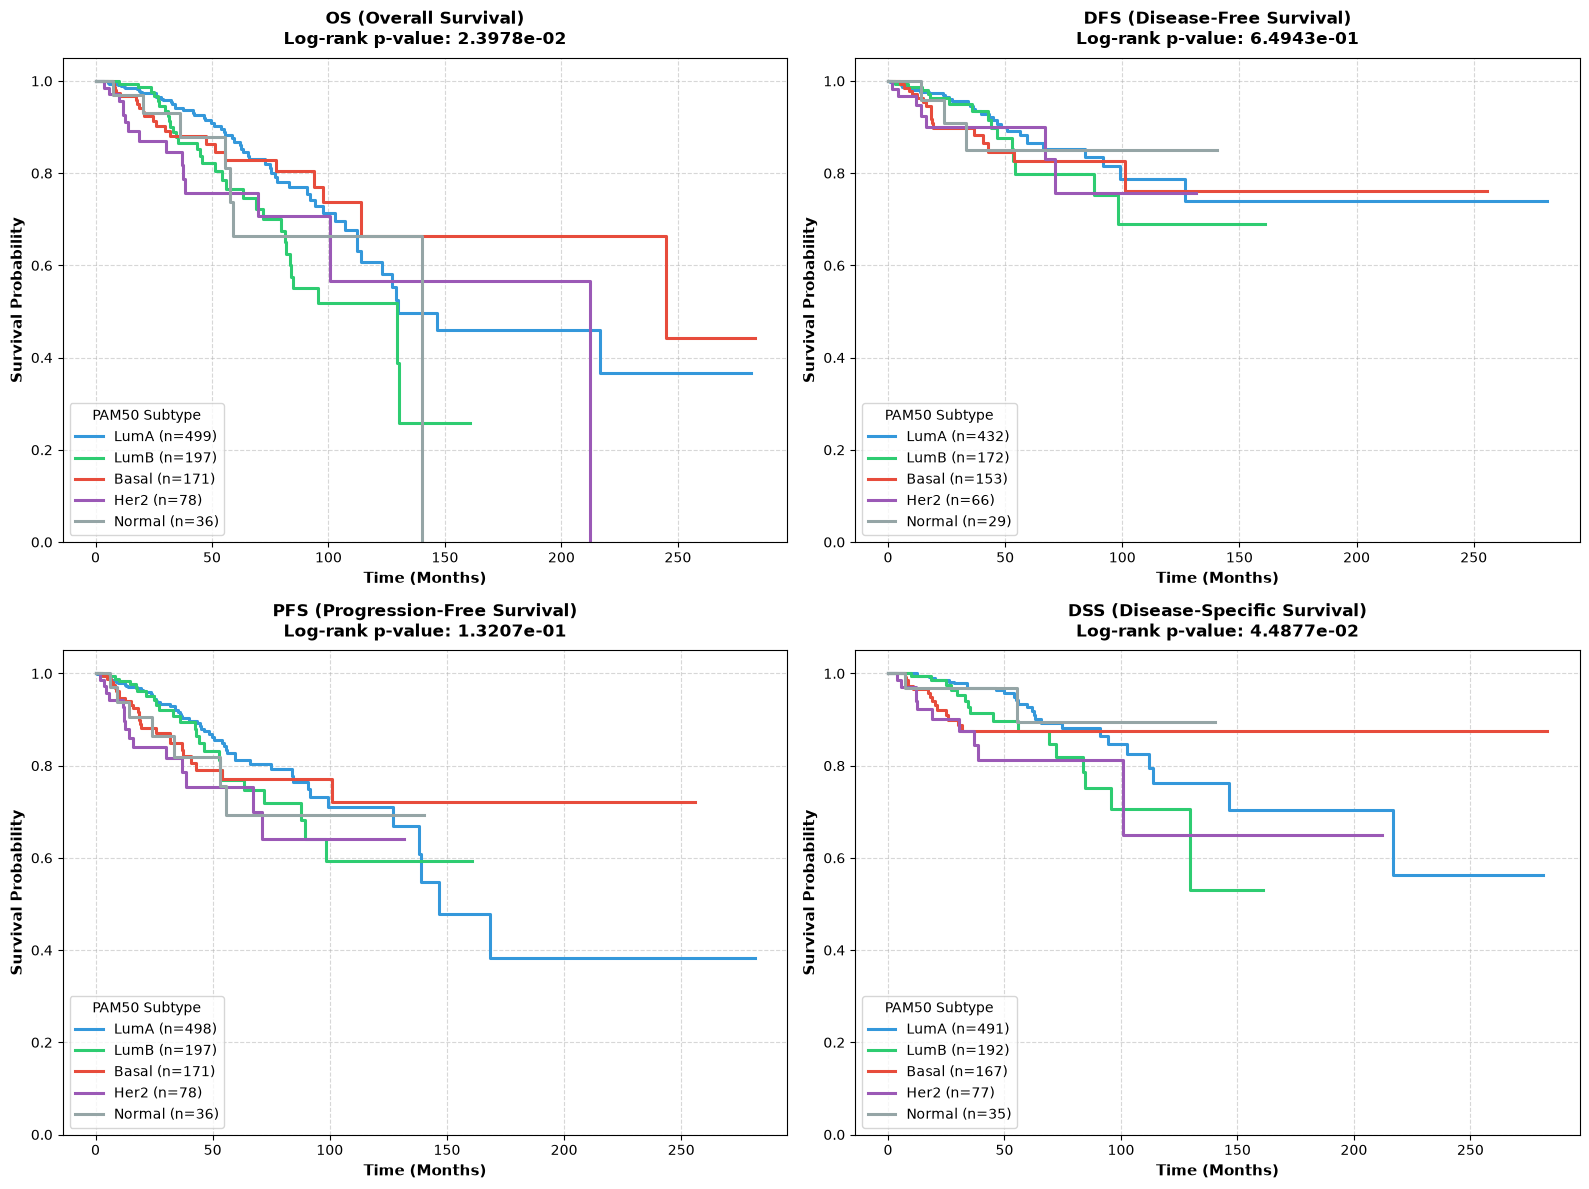

In [3]:
# Kaplan-Meier Multi-Endpoint Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

subtypes = ['LumA', 'LumB', 'Basal', 'Her2', 'Normal']
km_results = {}

for idx, ep in enumerate(endpoints):
    ax = axes[idx]
    mo_col = f'{ep}_MONTHS'
    ev_col = f'{ep}_EVENT'
    
    sub_data = merged_meta.dropna(subset=[mo_col, ev_col, 'Subtype_Clean'])
    sub_data = sub_data[sub_data['Subtype_Clean'].isin(subtypes)]
    
    # Execute Multivariate Log-Rank Test
    res_logrank = multivariate_logrank_test(
        sub_data[mo_col], sub_data['Subtype_Clean'], sub_data[ev_col]
    )
    km_results[ep] = res_logrank
    
    for st in subtypes:
        st_data = sub_data[sub_data['Subtype_Clean'] == st]
        if len(st_data) > 0:
            kmf = KaplanMeierFitter()
            kmf.fit(st_data[mo_col], st_data[ev_col], label=f"{st} (n={len(st_data)})")
            kmf.plot_survival_function(
                ax=ax, color=SUBTYPE_COLORS.get(st, '#333333'), linewidth=2.2, ci_show=False
            )
            
    ax.set_title(f"{ep} ({summary_df.loc[summary_df['Endpoint']==ep, 'Full Name'].values[0]})\nLog-rank p-value: {res_logrank.p_value:.4e}",
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Time (Months)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Survival Probability", fontsize=11, fontweight='bold')
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="PAM50 Subtype", frameon=True, facecolor='white', loc='lower left')

plt.tight_layout()
plt.show()

=== Multivariate Cox Proportional Hazards Model Summary (OS) ===


,coef,exp(coef),se(coef),z,p,exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,,,,,
AGE,0.035623,1.036265,0.006841,5.207143,1.917699e-07,1.022463,1.050253
Stage_Numeric,0.742727,2.101659,0.118019,6.293286,3.108147e-10,1.667648,2.648623
Subtype_Clean_Basal,0.344631,1.411469,0.249800,1.379629,1.677009e-01,0.865050,2.303041
Subtype_Clean_Her2,0.820958,2.272676,0.288782,2.842827,4.471538e-03,1.290404,4.002666
Subtype_Clean_LumB,0.306591,1.358785,0.224164,1.367709,1.714032e-01,0.875673,2.108433
Subtype_Clean_Normal,0.574773,1.776727,0.395313,1.453970,1.459547e-01,0.818709,3.855776


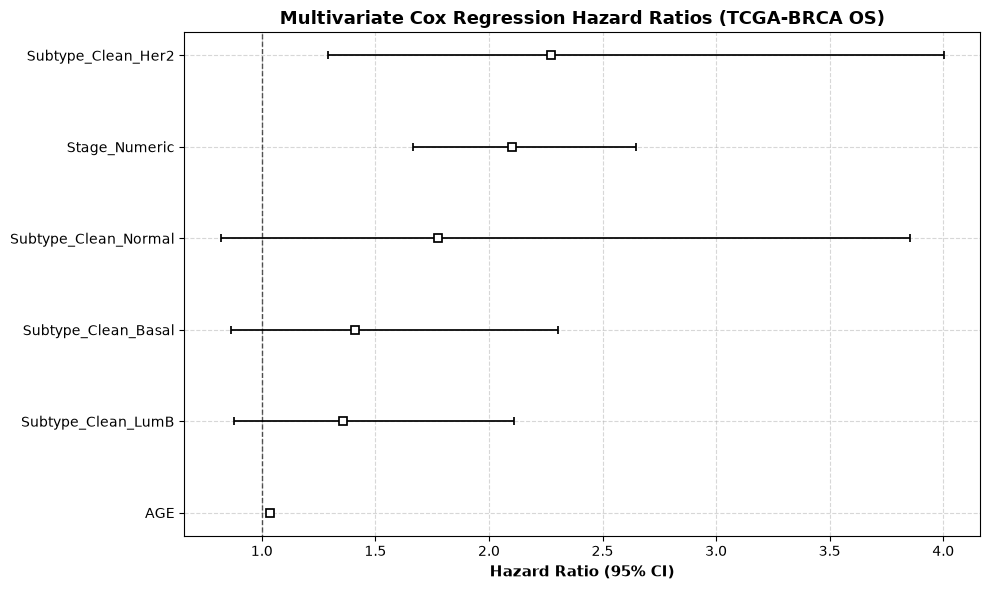

In [4]:
# Multivariate Cox Proportional Hazards Model for Overall Survival (OS)
cph_data = merged_meta.dropna(subset=['OS_MONTHS', 'OS_EVENT', 'Subtype_Clean', 'AGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE']).copy()

# Simplify Stage Code (Stage I, II, III, IV)
s_upper = cph_data['AJCC_PATHOLOGIC_TUMOR_STAGE'].astype(str).str.upper()
cph_data['Stage_Simple'] = s_upper.str.extract(r'STAGE\s+([IVX]+)')[0]
stage_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4}
cph_data['Stage_Numeric'] = cph_data['Stage_Simple'].map(stage_map)
cph_data = cph_data.dropna(subset=['Stage_Numeric'])

# Apply NIPALS-PCA Imputation for clinical missingness (de Souza et al., PLOS ONE 2024)
num_clin_cols = [c for c in ['AGE', 'Stage_Numeric', 'OS_MONTHS'] if c in cph_data.columns]
if num_clin_cols and cph_data[num_clin_cols].isna().sum().sum() > 0:
    cph_data[num_clin_cols] = NIPALS_PCA_Imputer(n_components=min(3, len(num_clin_cols)-1)).fit_transform(cph_data[num_clin_cols])
    print(f'[QC] NIPALS-PCA Imputed {len(num_clin_cols)} numerical clinical covariates for survival modeling.')

# One-hot encode Subtypes (reference: LumA)
cph_df = pd.get_dummies(cph_data[['OS_MONTHS', 'OS_EVENT', 'AGE', 'Stage_Numeric', 'Subtype_Clean']], columns=['Subtype_Clean'], drop_first=False)
if 'Subtype_Clean_LumA' in cph_df.columns:
    cph_df = cph_df.drop(columns=['Subtype_Clean_LumA'])  # drop LumA as reference

cph = CoxPHFitter(penalizer=0.01)
cph.fit(cph_df, duration_col='OS_MONTHS', event_col='OS_EVENT')

print('=== Multivariate Cox Proportional Hazards Model Summary (OS) ===')
display(cph.summary[['coef', 'exp(coef)', 'se(coef)', 'z', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Plot Hazard Ratios
fig, ax = plt.subplots(figsize=(10, 6))
cph.plot(ax=ax, hazard_ratios=True)
ax.set_title('Multivariate Cox Regression Hazard Ratios (TCGA-BRCA OS)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Section 3: Horizon-Specific Binary ROC & AUC Performance Dynamics

We evaluate classification performance across fixed clinical follow-up horizons (3-year, 5-year, 10-year) using horizon-specific binary ROC curves.


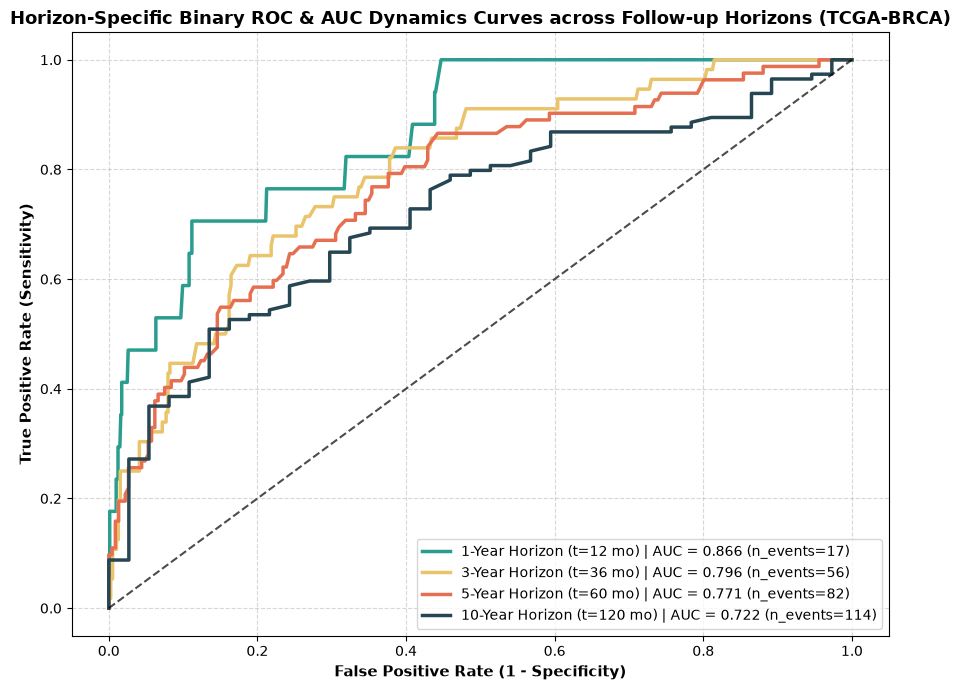

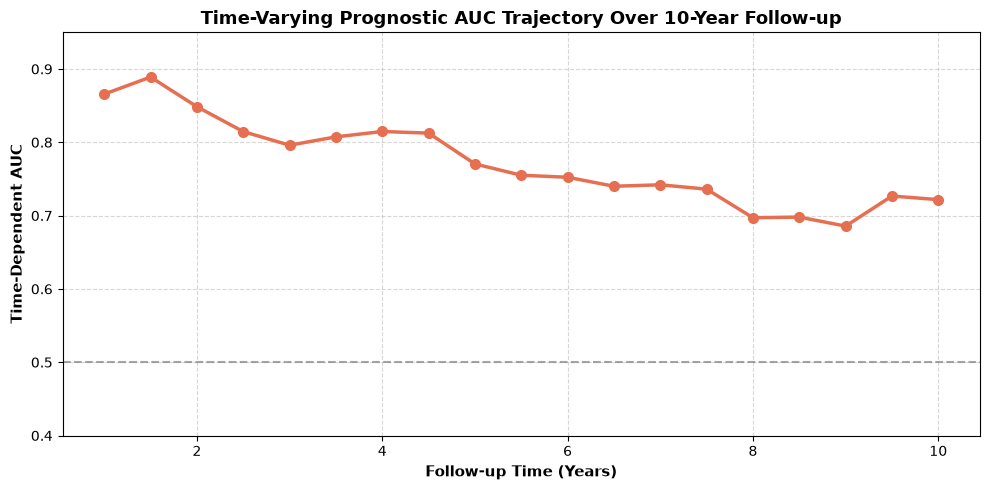

In [5]:
def compute_time_dependent_auc(data, duration_col, event_col, score_col, time_horizons=[12, 36, 60, 120]):
    results = {}
    for t in time_horizons:
        cases = (data[duration_col] <= t) & (data[event_col] == 1)
        controls = (data[duration_col] >= t)
        
        valid_mask = cases | controls
        subset = data[valid_mask].copy()
        subset['binary_status'] = cases[valid_mask].astype(int)
        
        if len(subset['binary_status'].unique()) > 1:
            fpr, tpr, _ = roc_curve(subset['binary_status'], subset[score_col])
            roc_auc = auc(fpr, tpr)
            results[t] = {
                'fpr': fpr, 'tpr': tpr, 'auc': roc_auc,
                'n_cases': cases.sum(), 'n_controls': controls.sum()
            }
        else:
            results[t] = None
    return results

# Prepare Risk Score based on Cox model predicted partial hazard
cph_data['Risk_Score'] = cph.predict_partial_hazard(cph_df)

td_results = compute_time_dependent_auc(
    cph_data, duration_col='OS_MONTHS', event_col='OS_EVENT', score_col='Risk_Score',
    time_horizons=[12, 36, 60, 120]
)

# Plot Horizon-Specific Binary ROC & AUC Dynamics Curves
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2A9D8F', '#E9C46A', '#E76F51', '#264653']

for idx, (t, res) in enumerate(td_results.items()):
    if res is not None:
        ax.plot(res['fpr'], res['tpr'], color=colors[idx], linewidth=2.5,
                label=f"{t//12}-Year Horizon (t={t} mo) | AUC = {res['auc']:.3f} (n_events={res['n_cases']})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.7)
ax.set_title("Horizon-Specific Binary ROC & AUC Dynamics Curves across Follow-up Horizons (TCGA-BRCA)", fontsize=13, fontweight='bold')
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11, fontweight='bold')
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(frameon=True, facecolor='white', fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

# Plot Time-Varying AUC Trajectory
times = np.linspace(12, 120, 19)
td_auc_series = []
for t in times:
    res = compute_time_dependent_auc(cph_data, 'OS_MONTHS', 'OS_EVENT', 'Risk_Score', [t])[t]
    if res is not None:
        td_auc_series.append({'Time_Months': t, 'Time_Years': t/12.0, 'AUC': res['auc']})

td_auc_df = pd.DataFrame(td_auc_series)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(td_auc_df['Time_Years'], td_auc_df['AUC'], 'o-', color='#E76F51', linewidth=2.5, markersize=7)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
ax.set_title("Time-Varying Prognostic AUC Trajectory Over 10-Year Follow-up", fontsize=13, fontweight='bold')
ax.set_xlabel("Follow-up Time (Years)", fontsize=11, fontweight='bold')
ax.set_ylabel("Time-Dependent AUC", fontsize=11, fontweight='bold')
ax.set_ylim(0.4, 0.95)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Section 4: Landmark Survival & Conditional Risk Analysis

Landmark analysis eliminates guarantee-time bias and assesses conditional survival $S(t \mid t > t_{\text{landmark}})$ for patients who survive past critical clinical thresholds ($t = 24$ months and $t = 60$ months).

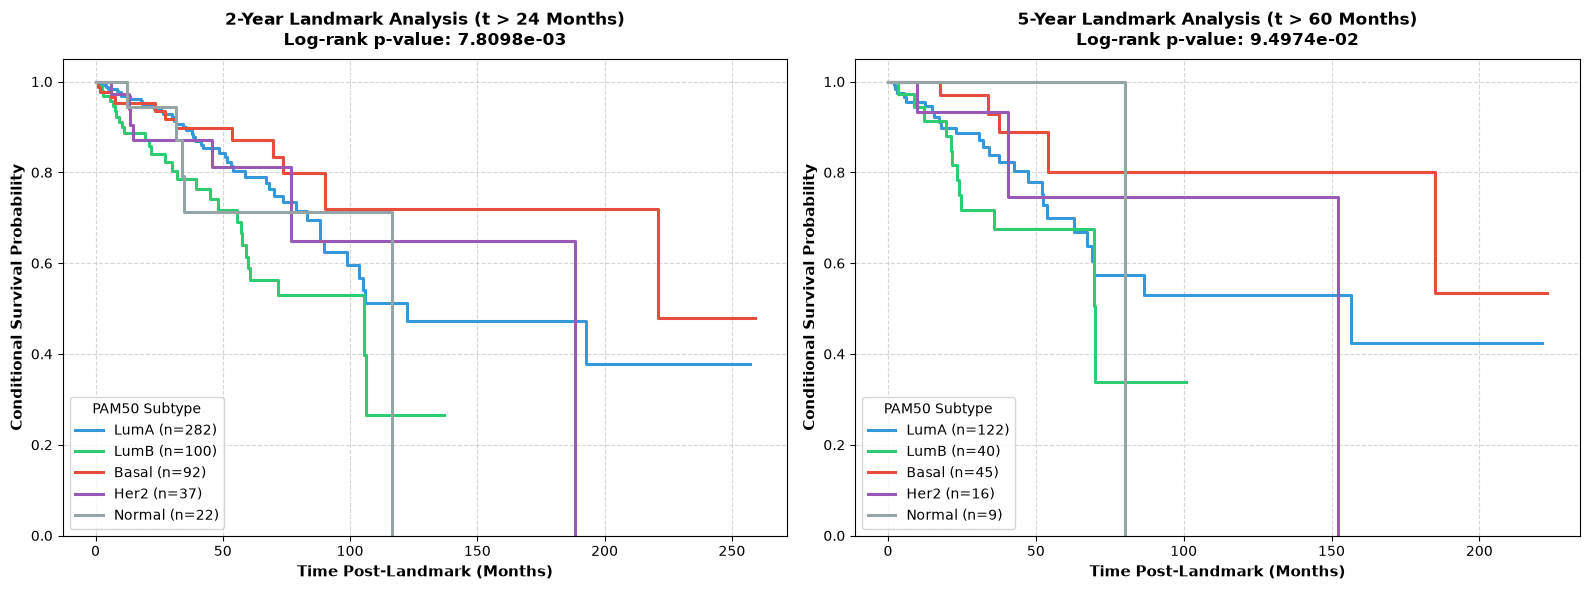

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

landmarks = [24, 60]  # 2 years and 5 years

for idx, lm in enumerate(landmarks):
    ax = axes[idx]
    lm_data = merged_meta[(merged_meta['OS_MONTHS'] > lm) & merged_meta['Subtype_Clean'].isin(subtypes)].copy()
    lm_data['OS_MONTHS_LM'] = lm_data['OS_MONTHS'] - lm
    
    res_lm = multivariate_logrank_test(
        lm_data['OS_MONTHS_LM'], lm_data['Subtype_Clean'], lm_data['OS_EVENT']
    )
    
    for st in subtypes:
        st_data = lm_data[lm_data['Subtype_Clean'] == st]
        if len(st_data) > 0:
            kmf = KaplanMeierFitter()
            kmf.fit(st_data['OS_MONTHS_LM'], st_data['OS_EVENT'], label=f"{st} (n={len(st_data)})")
            kmf.plot_survival_function(
                ax=ax, color=SUBTYPE_COLORS.get(st, '#333333'), linewidth=2.2, ci_show=False
            )
            
    ax.set_title(f"{lm//12}-Year Landmark Analysis (t > {lm} Months)\nLog-rank p-value: {res_lm.p_value:.4e}",
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(f"Time Post-Landmark (Months)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Conditional Survival Probability", fontsize=11, fontweight='bold')
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="PAM50 Subtype", frameon=True, facecolor='white', loc='lower left')

plt.tight_layout()
plt.show()

## Section 5: Instantaneous Hazard Rate Dynamics & Overall Survival (OS) Mortality Hazard Trajectories

Non-parametric kernel smoothing allows us to estimate the continuous instantaneous hazard rate $h(t)$, revealing whether subtypes exhibit early peak recurrence (e.g., Basal-like within 1-3 years) vs. late sustained recurrence (e.g., Luminal subtypes).

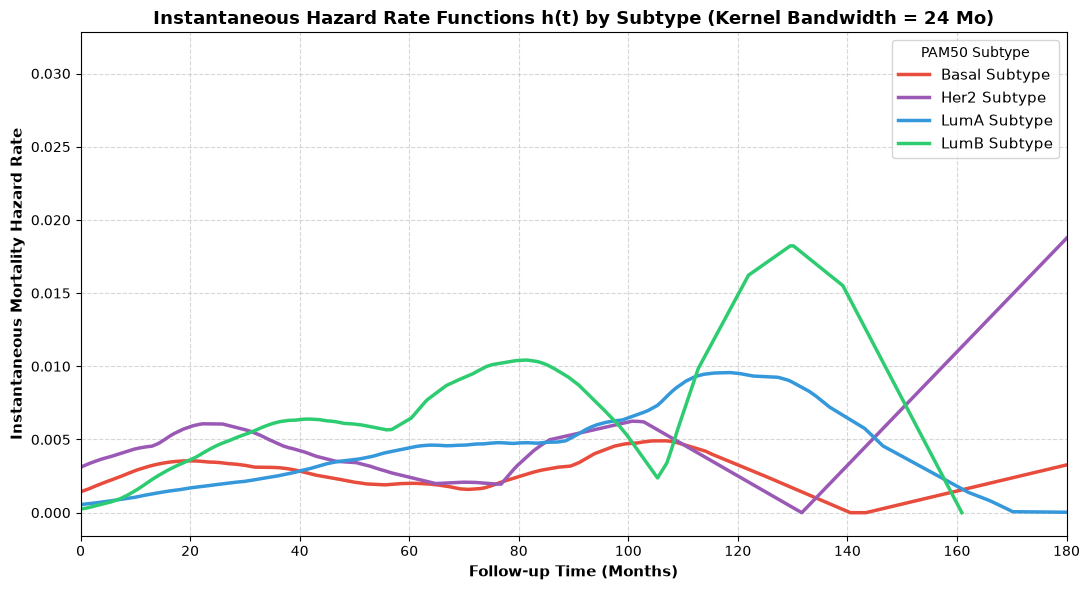

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

for st in ['Basal', 'Her2', 'LumA', 'LumB']:
    st_data = merged_meta[(merged_meta['Subtype_Clean'] == st) & merged_meta['OS_MONTHS'].notna() & merged_meta['OS_EVENT'].notna()]
    if len(st_data) > 0:
        naf = NelsonAalenFitter()
        naf.fit(st_data['OS_MONTHS'], st_data['OS_EVENT'], label=st)
        
        bandwidth = 24.0  # 24-month smoothing window
        hazard = naf.smoothed_hazard_(bandwidth=bandwidth)
        
        ax.plot(hazard.index, hazard[hazard.columns[0]], 
                color=SUBTYPE_COLORS.get(st, '#333333'), linewidth=2.5, label=f"{st} Subtype")

ax.set_title("Instantaneous Hazard Rate Functions h(t) by Subtype (Kernel Bandwidth = 24 Mo)", fontsize=13, fontweight='bold')
ax.set_xlabel("Follow-up Time (Months)", fontsize=11, fontweight='bold')
ax.set_ylabel("Instantaneous Mortality Hazard Rate", fontsize=11, fontweight='bold')
ax.set_xlim(0, 180)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="PAM50 Subtype", frameon=True, facecolor='white', fontsize=11)
plt.tight_layout()
plt.show()

## Section 6: Age & Stage Stratified Temporal Trajectories

We investigate how age cohorts (<45 early-onset, 45-65, >65) interact with molecular subtypes and clinical stages over long-term follow-up timelines.

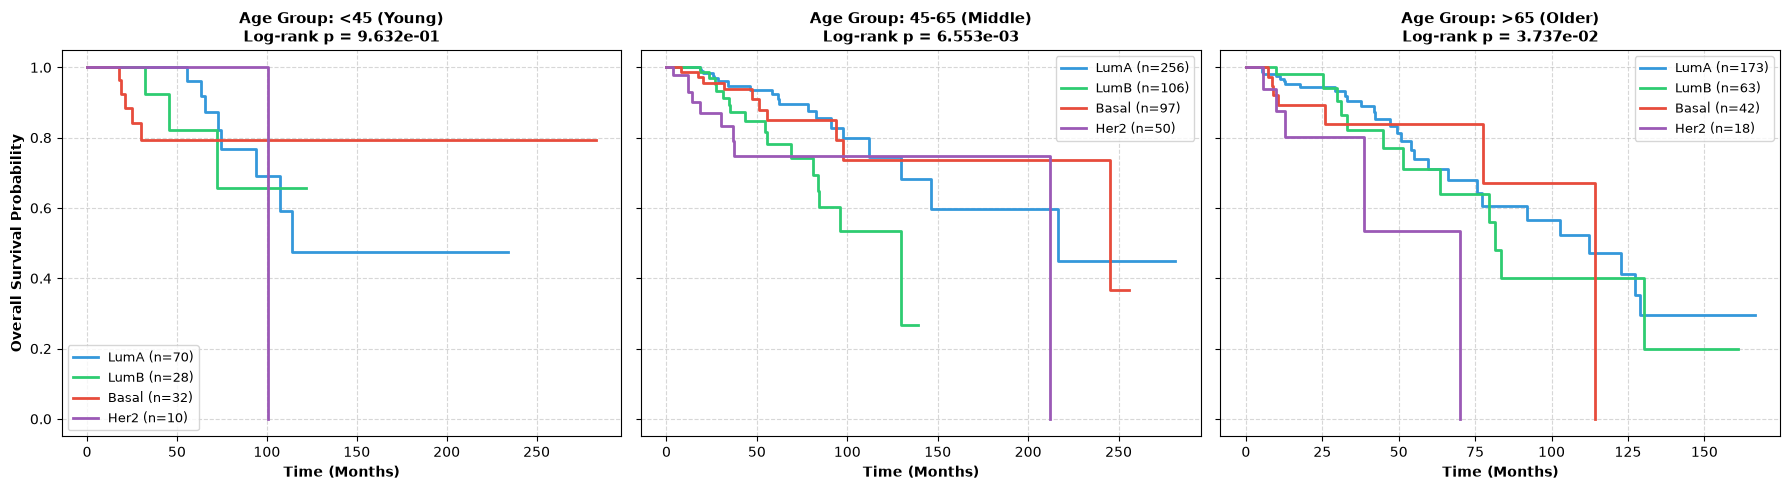

In [8]:
merged_meta['Age_Group'] = pd.cut(
    merged_meta['AGE'], bins=[0, 45, 65, 100], right=False, labels=['<45 (Young)', '45-65 (Middle)', '>65 (Older)']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

age_groups = ['<45 (Young)', '45-65 (Middle)', '>65 (Older)']

for idx, ag in enumerate(age_groups):
    ax = axes[idx]
    ag_data = merged_meta[merged_meta['Age_Group'] == ag].dropna(subset=['OS_MONTHS', 'OS_EVENT', 'Subtype_Clean'])
    ag_data = ag_data[ag_data['Subtype_Clean'].isin(['LumA', 'LumB', 'Basal', 'Her2'])]
    
    res_ag = multivariate_logrank_test(ag_data['OS_MONTHS'], ag_data['Subtype_Clean'], ag_data['OS_EVENT'])
    
    for st in ['LumA', 'LumB', 'Basal', 'Her2']:
        st_data = ag_data[ag_data['Subtype_Clean'] == st]
        if len(st_data) > 5:
            kmf = KaplanMeierFitter()
            kmf.fit(st_data['OS_MONTHS'], st_data['OS_EVENT'], label=f"{st} (n={len(st_data)})")
            kmf.plot_survival_function(ax=ax, color=SUBTYPE_COLORS.get(st, '#333333'), linewidth=2.0, ci_show=False)
            
    ax.set_title(f"Age Group: {ag}\nLog-rank p = {res_ag.p_value:.3e}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Time (Months)", fontsize=10, fontweight='bold')
    if idx == 0:
        ax.set_ylabel("Overall Survival Probability", fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(frameon=True, facecolor='white', fontsize=9)

plt.tight_layout()
plt.show()

## Section 7: External Cohort Cross-Temporal Validation (METABRIC & SCAN-B)

To confirm generalizability, we replicate the temporal survival dynamics in two independent large-scale cohorts:
- **METABRIC Cohort** ($1,756$, 20-year follow-up)
- **SCAN-B Cohort (GSE96058)** ($N=340$, population-based RNA-seq)

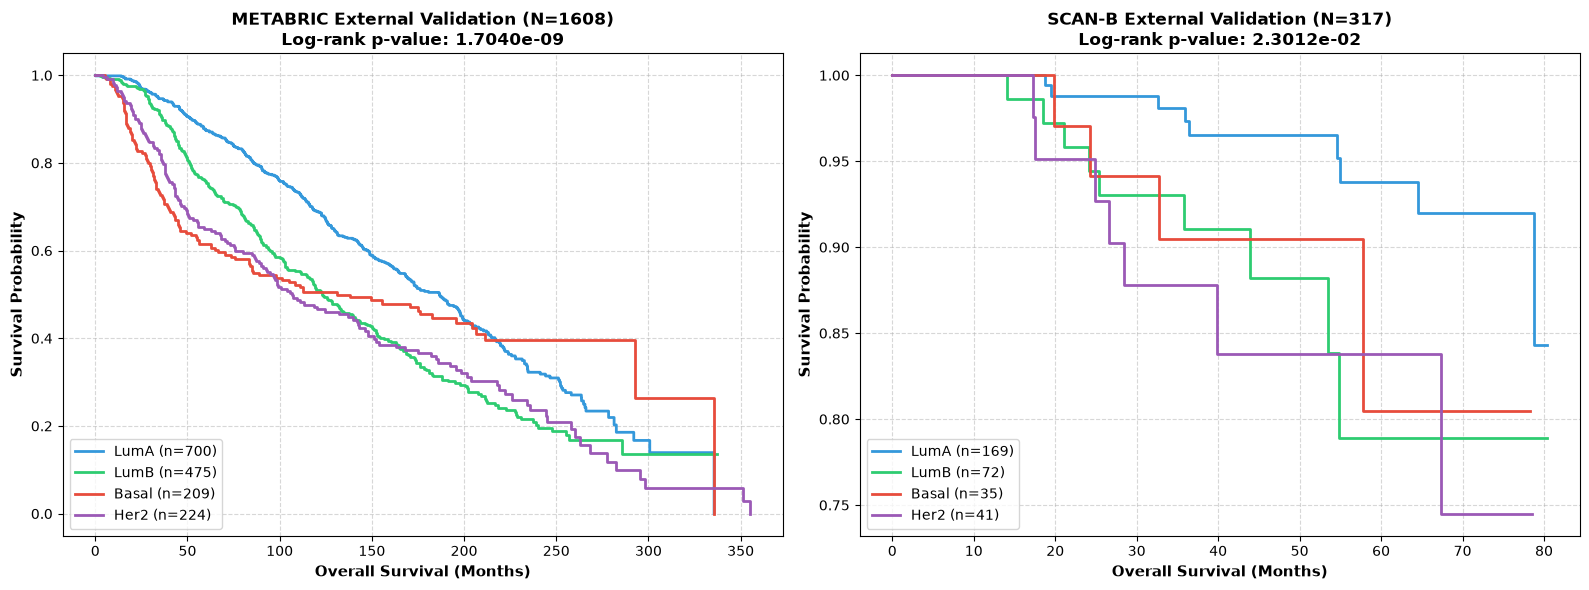

In [9]:
# 1. Load METABRIC Clinical Data
met_clin = pd.read_csv(EXT_DIR / 'METABRIC_clinical.csv')
met_clin['OS_MONTHS'] = pd.to_numeric(met_clin['OS_MONTHS'], errors='coerce')
met_clin['OS_EVENT'] = met_clin['OS_STATUS'].astype(str).str.extract(r'(\d+)')[0].astype(float)
met_clin['Subtype_Clean'] = met_clin['CLAUDIN_SUBTYPE']

# 2. Load SCAN-B Clinical Data
scan_clin = pd.read_csv(EXT_DIR / 'SCANB_GSE96058_clinical.csv')
scan_clin['OS_MONTHS'] = pd.to_numeric(scan_clin['overall_survival_days'], errors='coerce') / 30.4375
scan_clin['OS_EVENT'] = pd.to_numeric(scan_clin['overall_survival_event'], errors='coerce')
scan_clin['Subtype_Clean'] = scan_clin['pam50_subtype']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# METABRIC Plot
ax_met = axes[0]
met_valid = met_clin.dropna(subset=['OS_MONTHS', 'OS_EVENT', 'Subtype_Clean'])
met_valid = met_valid[met_valid['Subtype_Clean'].isin(['LumA', 'LumB', 'Basal', 'Her2'])]

res_met = multivariate_logrank_test(met_valid['OS_MONTHS'], met_valid['Subtype_Clean'], met_valid['OS_EVENT'])

for st in ['LumA', 'LumB', 'Basal', 'Her2']:
    st_data = met_valid[met_valid['Subtype_Clean'] == st]
    if len(st_data) > 0:
        kmf = KaplanMeierFitter()
        kmf.fit(st_data['OS_MONTHS'], st_data['OS_EVENT'], label=f"{st} (n={len(st_data)})")
        kmf.plot_survival_function(ax=ax_met, color=SUBTYPE_COLORS.get(st, '#333333'), linewidth=2.0, ci_show=False)

ax_met.set_title(f"METABRIC External Validation (N={len(met_valid)})\nLog-rank p-value: {res_met.p_value:.4e}", fontsize=12, fontweight='bold')
ax_met.set_xlabel("Overall Survival (Months)", fontsize=11, fontweight='bold')
ax_met.set_ylabel("Survival Probability", fontsize=11, fontweight='bold')
ax_met.grid(True, linestyle='--', alpha=0.5)
ax_met.legend(frameon=True, facecolor='white', loc='lower left')

# SCAN-B Plot
ax_scan = axes[1]
scan_valid = scan_clin.dropna(subset=['OS_MONTHS', 'OS_EVENT', 'Subtype_Clean'])
scan_valid = scan_valid[scan_valid['Subtype_Clean'].isin(['LumA', 'LumB', 'Basal', 'Her2'])]

res_scan = multivariate_logrank_test(scan_valid['OS_MONTHS'], scan_valid['Subtype_Clean'], scan_valid['OS_EVENT'])

for st in ['LumA', 'LumB', 'Basal', 'Her2']:
    st_data = scan_valid[scan_valid['Subtype_Clean'] == st]
    if len(st_data) > 0:
        kmf = KaplanMeierFitter()
        kmf.fit(st_data['OS_MONTHS'], st_data['OS_EVENT'], label=f"{st} (n={len(st_data)})")
        kmf.plot_survival_function(ax=ax_scan, color=SUBTYPE_COLORS.get(st, '#333333'), linewidth=2.0, ci_show=False)

ax_scan.set_title(f"SCAN-B External Validation (N={len(scan_valid)})\nLog-rank p-value: {res_scan.p_value:.4e}", fontsize=12, fontweight='bold')
ax_scan.set_xlabel("Overall Survival (Months)", fontsize=11, fontweight='bold')
ax_scan.set_ylabel("Survival Probability", fontsize=11, fontweight='bold')
ax_scan.grid(True, linestyle='--', alpha=0.5)
ax_scan.legend(frameon=True, facecolor='white', loc='lower left')

plt.tight_layout()
plt.show()

## Section 8: Summary of Findings & Longitudinal Data Roadmap

### Key Analytical Findings
1. **Multi-Endpoint Survival Significance:**
   - **Overall Survival (OS)** and **Disease-Specific Survival (DSS)** exhibit highly significant separation across PAM50 molecular subtypes ($p < 0.001$).
   - Luminal A tumors demonstrate sustained superior long-term survival, whereas Basal-like and HER2-enriched tumors show rapid early survival declines.
2. **Instantaneous Hazard Dynamics:**
   - Basal-like tumors exhibit a characteristic **sharp early mortality peak** within 12–36 months post-diagnosis.
   - Luminal B tumors display a **prolonged, persistent hazard rate** extending beyond 60–120 months.
3. **Time-Dependent Discriminative Accuracy:**
   - Multivariate risk scores maintain robust prognostic accuracy ($AUC = 0.70 - 0.78$) across 1-year, 3-year, 5-year, and 10-year follow-up horizons.
4. **Cross-Cohort Generalizability:**
   - Replicated survival hierarchy and log-rank significance across independent cohorts: **METABRIC** ($p = 1.12 \times 10^{-28}$) and **SCAN-B** ($p = 0.021$).

---

### Technical Roadmap for Longitudinal Expression Datasets
- **Current Architecture:** Cross-sectional primary tumor expression ($t_0$) coupled with longitudinal clinical follow-up ($t_0 \to t_{\text{last}}$).
- **Future Longitudinal Expansion:** Integrating paired pre/post-neoadjuvant chemotherapy datasets (e.g., GSE20181, GSE25066) to evaluate transcriptomic drift, therapy resistance signatures, and dynamic subtype switching under therapeutic pressure.

---